In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. 加载数据
filepath = "/data/nishome/xuhaochen/Time-Series-Library/dataset/ETT-small/ETTh1.csv"
df_raw = pd.read_csv(filepath)

# 2. 设置与原始类一致的参数 (假设是多变量任务 'M')
features = 'M' 
target = 'OT'
# 这里的 seq_len 会影响验证集和测试集的起始点，但计算全局 scale 时主要看训练集 border
seq_len = 96 

# 3. 提取特征列 (跳过第一列 date)
if features == 'M' or features == 'MS':
    cols_data = df_raw.columns[1:]
    df_data = df_raw[cols_data]
elif features == 'S':
    df_data = df_raw[[target]]

train_start = 0
train_end = 12 * 30 * 24 
# 5. 执行归一化逻辑并提取参数
scaler = StandardScaler()
train_data = df_data.iloc[train_start:train_end]

# 只在训练集上 fit
scaler.fit(train_data.values)

data = scaler.transform(df_data.values)

data

array([[-0.36312285, -0.0057598 , -0.63071223, ...,  1.38857471,
         0.87514257,  1.46055158],
       [-0.38617567,  0.02629596, -0.65010053, ...,  1.32897674,
         0.92433047,  1.16152666],
       [-0.47838673, -0.13398305, -0.68869591, ...,  0.97236495,
         0.68156452,  1.16152666],
       ...,
       [-0.88163826,  0.8597471 , -1.06848906, ...,  0.91276699,
         1.16550965, -0.74726404],
       [ 0.22455084,  0.8597471 ,  0.07107161, ...,  0.85316879,
         1.0211195 , -0.80098829],
       [ 0.37439393,  0.7315238 ,  0.1999041 , ...,  0.91276699,
         1.06872062, -0.82398177]])

开始特征动力学分析，寻找最佳带宽...
Feature: HUFL       | Optimal Bandwidth h: 2.00
Feature: HULL       | Optimal Bandwidth h: 2.00
Feature: MUFL       | Optimal Bandwidth h: 2.00
Feature: MULL       | Optimal Bandwidth h: 2.00
Feature: LUFL       | Optimal Bandwidth h: 2.00
Feature: LULL       | Optimal Bandwidth h: 2.00
Feature: OT         | Optimal Bandwidth h: 2.00


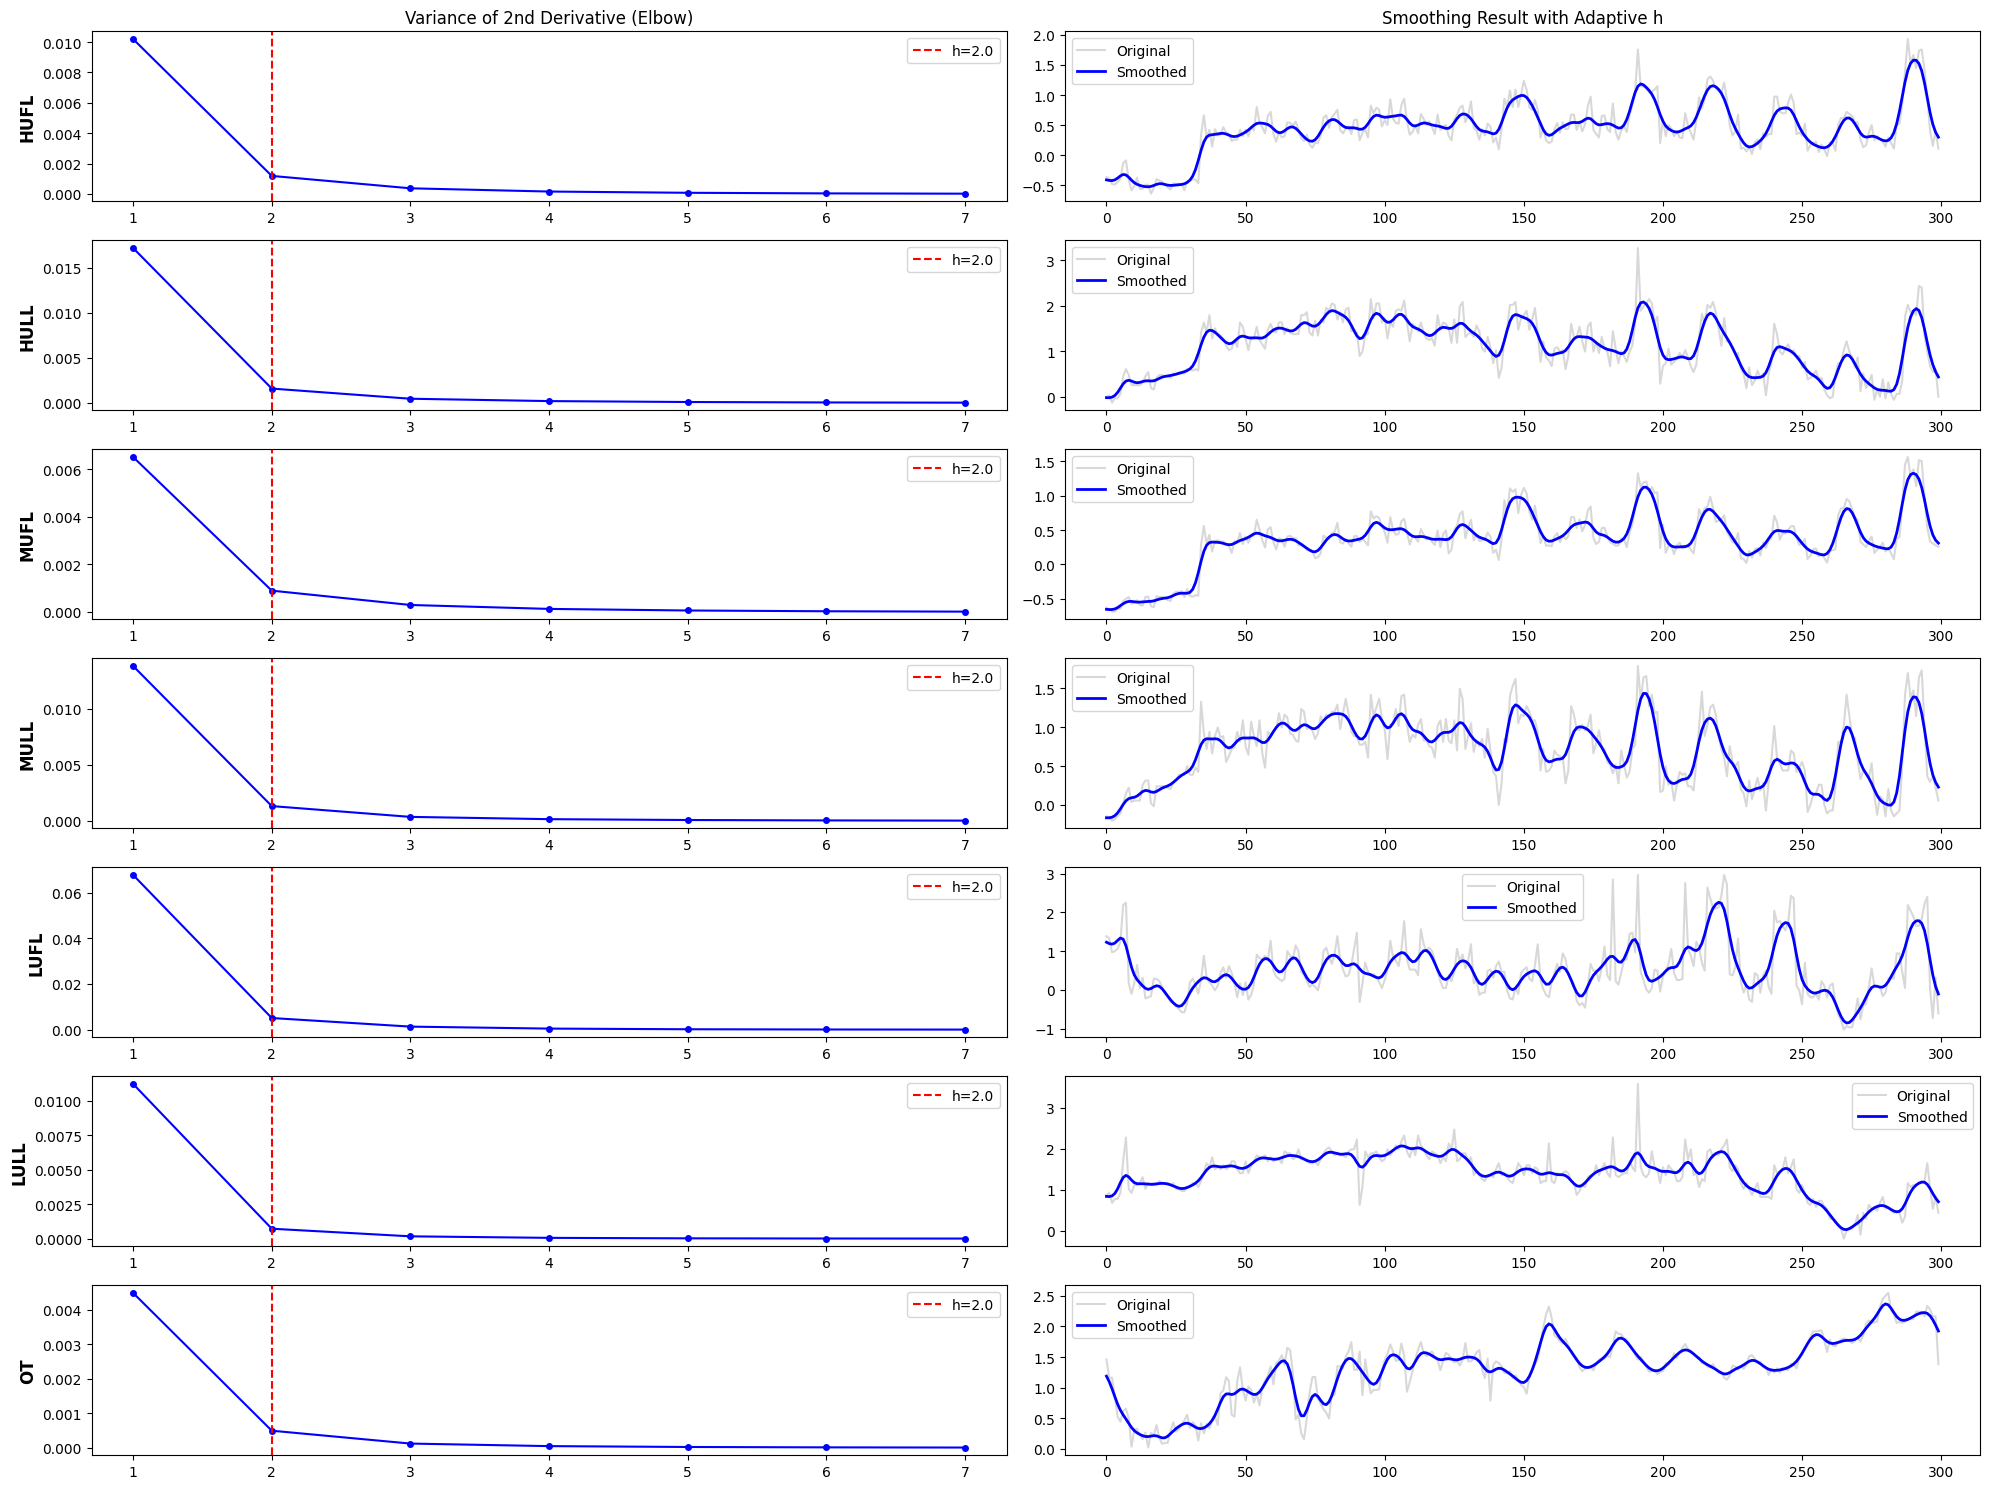

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 解析高斯核平滑及二阶导数函数 (针对 Loss 优化的解析版本)
# ---------------------------------------------------------
def get_gaussian_derivatives(data, h):
    n = len(data)
    x = np.arange(n)
    smoothed = np.zeros(n)
    d2 = np.zeros(n)
    
    h2 = h**2
    h4 = h**4
    
    for t in range(n):
        dist = x - t
        weights = np.exp(-0.5 * (dist / h)**2)
        
        # 权重及其二阶导数权重
        w_pp = weights * (dist**2 / h4 - 1/h2)
        
        sum_w = np.sum(weights)
        sum_w_pp = np.sum(w_pp)
        sum_yw = np.sum(weights * data)
        sum_yw_pp = np.sum(w_pp * data)
        
        # 商法则求二阶导 (简化版，侧重于捕捉曲率能量)
        smoothed[t] = sum_yw / sum_w
        d2[t] = (sum_yw_pp * sum_w - sum_yw * sum_w_pp) / (sum_w**2)
        
    return smoothed, d2

# ---------------------------------------------------------
# 2. 自动化寻找“肘部”带宽的函数
# ---------------------------------------------------------
def find_optimal_h_via_elbow(feature_data, h_range):
    variances = []
    # 为了计算效率，取前 1000 个点进行带宽搜索
    sample_data = feature_data[:1000]
    
    for h in h_range:
        _, d2 = get_gaussian_derivatives(sample_data, h)
        # 计算二阶导数的方差，代表曲率能量
        variances.append(np.var(d2))
    
    variances = np.array(variances)
    
    # 寻找肘部点 (Knee Point): 
    # 逻辑：寻找距离“起点-终点连线”最远的点
    coords = np.vstack((h_range, variances)).T
    first_pt = coords[0]
    last_pt = coords[-1]
    line_vec = last_pt - first_pt
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = coords - first_pt
    scalar_product = np.sum(vec_from_first * line_vec_norm, axis=1)
    vec_to_line = vec_from_first - np.outer(scalar_product, line_vec_norm)
    dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
    
    best_h = h_range[np.argmax(dist_to_line)]
    return best_h, variances

# ---------------------------------------------------------
# 3. 遍历 ETT 的 7 个特征执行自动化分析
# ---------------------------------------------------------
# 这里的 data 是你之前代码里 scaler.transform 后的 (8640+, 7) 数组
column_names = df_data.columns
h_candidates = np.linspace(1, 7, 7)
optimal_hs = {}

print("开始特征动力学分析，寻找最佳带宽...")

plt.figure(figsize=(20, 15))

for i, col in enumerate(column_names):
    feature_series = data[train_start:train_end, i]
    
    # 执行自动化带宽搜索
    best_h, vars_list = find_optimal_h_via_elbow(feature_series, h_candidates)
    optimal_hs[col] = best_h
    print(f"Feature: {col:10s} | Optimal Bandwidth h: {best_h:.2f}")
    
    # 可视化 1: 肘部曲线
    plt.subplot(7, 2, 2*i + 1)
    plt.plot(h_candidates, vars_list, 'b-o', markersize=4)
    plt.axvline(best_h, color='red', linestyle='--', label=f'h={best_h:.1f}')
    if i == 0: plt.title("Variance of 2nd Derivative (Elbow)")
    plt.ylabel(col, fontsize=12, fontweight='bold')
    plt.legend()
    
    # 可视化 2: 平滑效果展示 (局部前 300 点)
    plt.subplot(7, 2, 2*i + 2)
    sample_view = feature_series[:300]
    s_curve, _ = get_gaussian_derivatives(sample_view, best_h)
    plt.plot(sample_view, color='gray', alpha=0.3, label='Original')
    plt.plot(s_curve, color='blue', linewidth=2, label='Smoothed')
    if i == 0: plt.title("Smoothing Result with Adaptive h")
    plt.legend()

plt.tight_layout()
plt.show()